# Exploratory Data Analysis — Traffic Sign Dataset

Run `python data/download_data.py` first to generate `data/gtsdb_yolo/`.

In [1]:
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from PIL import Image

DATA_DIR = Path('../data/gtsdb_yolo')
with open(DATA_DIR / 'data.yaml') as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg['names']
print(f"{len(class_names)} classes")

43 classes


## 1. Class distribution
Check for imbalance -- this drives augmentation/sampling decisions in `train.py`.

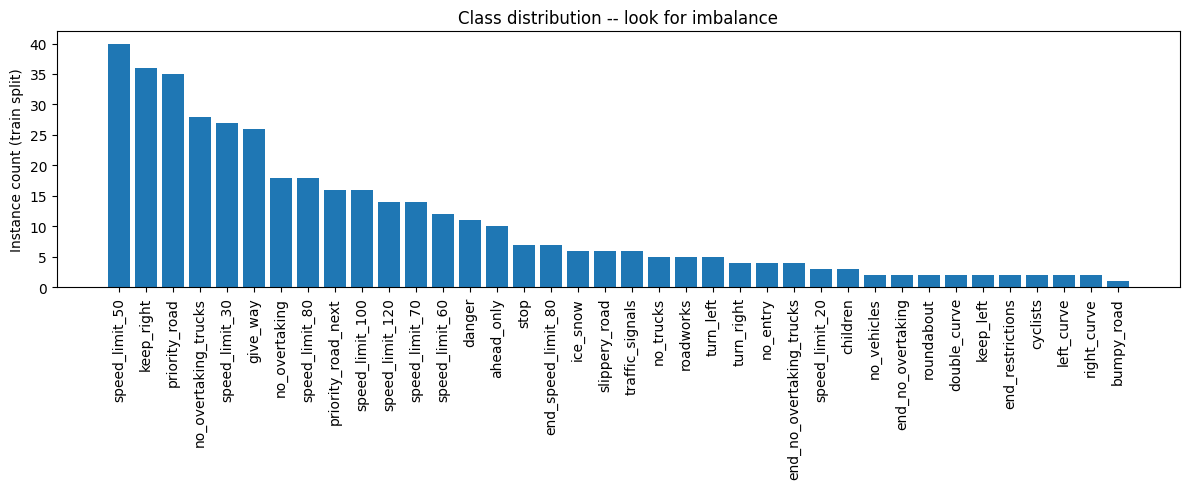

In [2]:
def count_classes(split):
    label_dir = DATA_DIR / 'labels' / split
    counts = Counter()
    for label_file in label_dir.glob('*.txt'):
        for line in label_file.read_text().strip().splitlines():
            if line:
                class_id = int(line.split()[0])
                counts[class_names[class_id]] += 1
    return counts

train_counts = count_classes('train')
names_sorted = sorted(train_counts, key=train_counts.get, reverse=True)

plt.figure(figsize=(12, 5))
plt.bar(names_sorted, [train_counts[n] for n in names_sorted])
plt.xticks(rotation=90)
plt.ylabel('Instance count (train split)')
plt.title('Class distribution -- look for imbalance')
plt.tight_layout()
plt.show()

## 2. Image size / box size distribution
Small bounding boxes (distant signs) are typically the hardest detections.

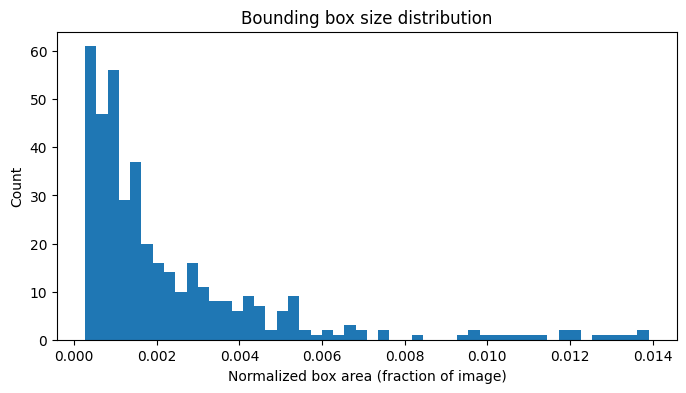

Median box area: 0.0014
% of boxes under 1% of image area: 96.3%


In [3]:
def box_areas(split):
    label_dir = DATA_DIR / 'labels' / split
    areas = []
    for label_file in label_dir.glob('*.txt'):
        for line in label_file.read_text().strip().splitlines():
            if line:
                _, xc, yc, w, h = map(float, line.split())
                areas.append(w * h)  # normalized area
    return areas

areas = box_areas('train')
plt.figure(figsize=(8, 4))
plt.hist(areas, bins=50)
plt.xlabel('Normalized box area (fraction of image)')
plt.ylabel('Count')
plt.title('Bounding box size distribution')
plt.show()

print(f"Median box area: {sorted(areas)[len(areas)//2]:.4f}")
print(f"% of boxes under 1% of image area: {sum(1 for a in areas if a < 0.01) / len(areas) * 100:.1f}%")

## 3. Sample images with annotations
Sanity-check that the YOLO label conversion in `download_data.py` is correct.

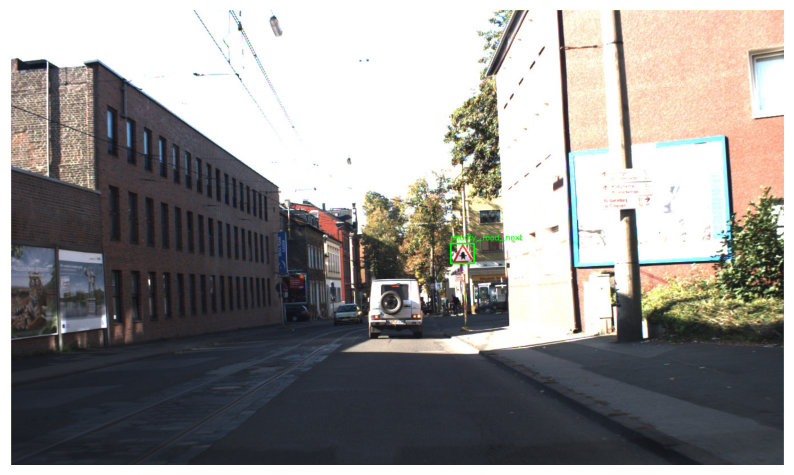

In [4]:
import cv2

def show_sample(split, idx=0):
    img_dir = DATA_DIR / 'images' / split
    label_dir = DATA_DIR / 'labels' / split
    img_path = sorted(img_dir.glob('*.jpg'))[idx]
    label_path = label_dir / f'{img_path.stem}.txt'

    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    for line in label_path.read_text().strip().splitlines():
        class_id, xc, yc, bw, bh = map(float, line.split())
        x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
        x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, class_names[int(class_id)], (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

show_sample('train', idx=0)